# Exploratory Data Analysis: AML Transactions
Explores the `HI-Small_Trans.csv` dataset.

**Set `DATA_PATH` below to point at your local copy of the CSV.**
On LUMI this will be something like `/scratch/project_xxx/HI-Small_Trans.csv`.

# Install required dependencies

In [4]:
!pip install -q torch pennylane pennylane-qiskit qiskit-iqm iqm-client flwr pandas scikit-learn matplotlib seaborn jupyter plotly


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

# --- SET YOUR DATA PATH HERE ---
# Updated to your specified LUMI scratch directory
DATA_PATH = '/scratch/project_465003017/JunctionHackathon/op_project/HI-Small_Trans.csv'

In [6]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} transactions, {df.shape[1]} columns')
df.head()

Loaded 5,078,345 transactions, 11 columns


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [7]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [8]:
# Filter to a specific bank (fixed: == not =)
bank_001 = df[df['From Bank'] == '001']
print(f"Bank 001 transactions: {len(bank_001):,}")
bank_001.head()

Bank 001 transactions: 0


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering


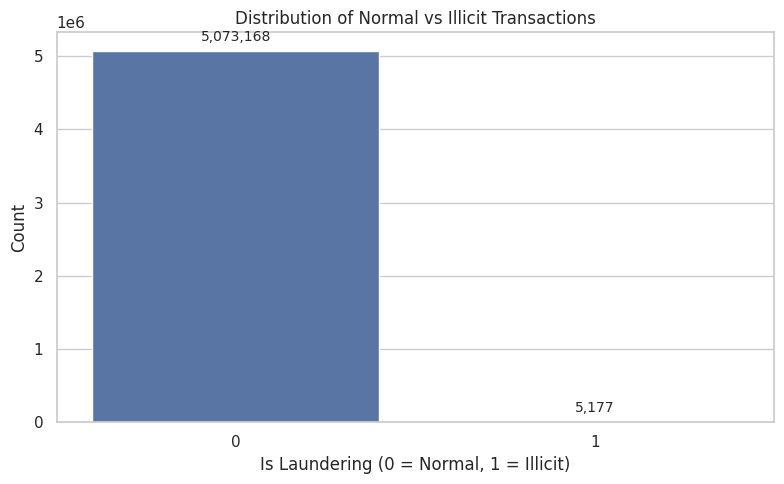

Normal : 5,073,168  (99.90%)
Illicit: 5,177  (0.10%)


In [9]:
# Class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Is Laundering')
plt.title('Distribution of Normal vs Illicit Transactions')
plt.xlabel('Is Laundering (0 = Normal, 1 = Illicit)')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, xytext=(0, 5),
        textcoords='offset points'
    )
plt.tight_layout()
plt.show()

n_normal   = (df['Is Laundering'] == 0).sum()
n_illicit  = (df['Is Laundering'] == 1).sum()
print(f'Normal : {n_normal:,}  ({n_normal/len(df)*100:.2f}%)')
print(f'Illicit: {n_illicit:,}  ({n_illicit/len(df)*100:.2f}%)')

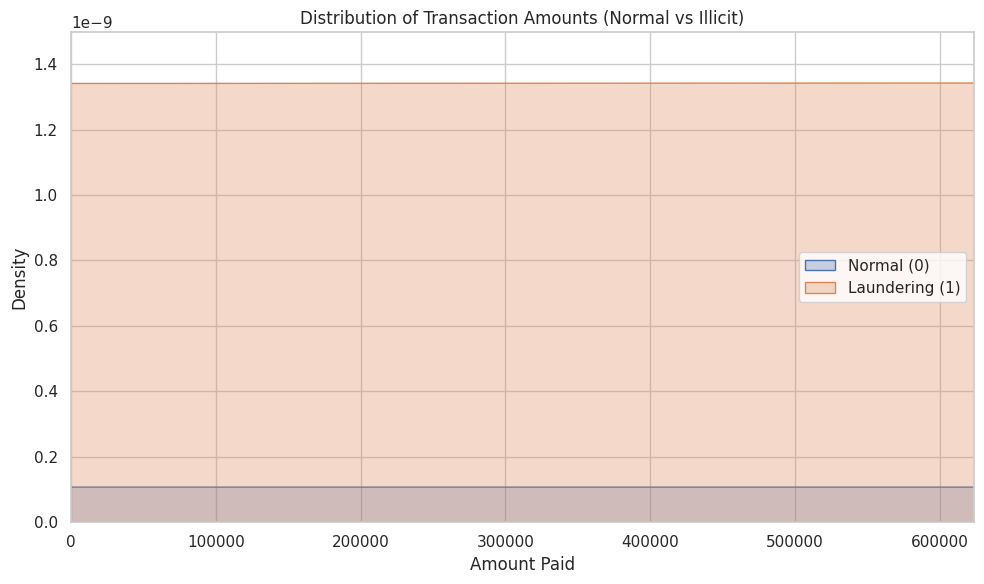

In [10]:
# Transaction amount distribution by class
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Is Laundering'] == 0], x='Amount Paid', label='Normal (0)',    fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Is Laundering'] == 1], x='Amount Paid', label='Laundering (1)', fill=True, alpha=0.3)
plt.title('Distribution of Transaction Amounts (Normal vs Illicit)')
plt.xlim(0, df['Amount Paid'].quantile(0.95))
plt.legend()
plt.tight_layout()
plt.show()

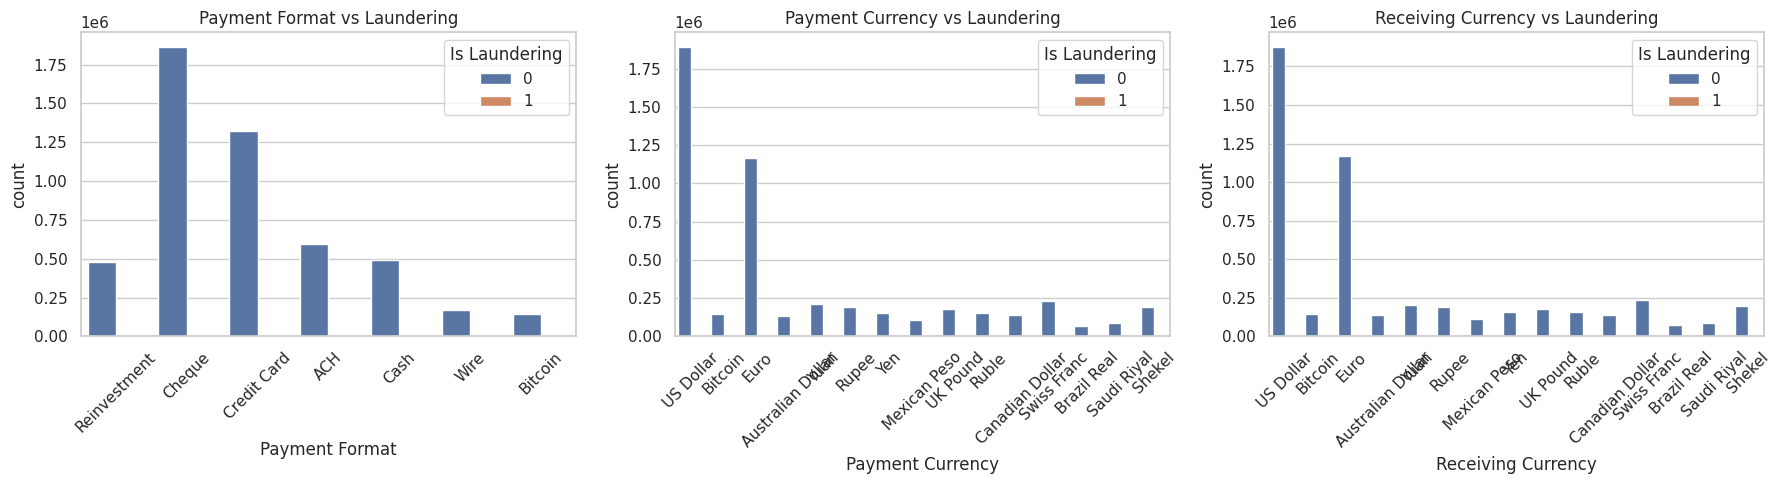

In [11]:
# Categorical feature analysis
categorical_cols = ['Payment Format', 'Payment Currency', 'Receiving Currency']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    if col in df.columns:
        sns.countplot(data=df, x=col, hue='Is Laundering', ax=axes[i])
        axes[i].set_title(f'{col} vs Laundering')
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

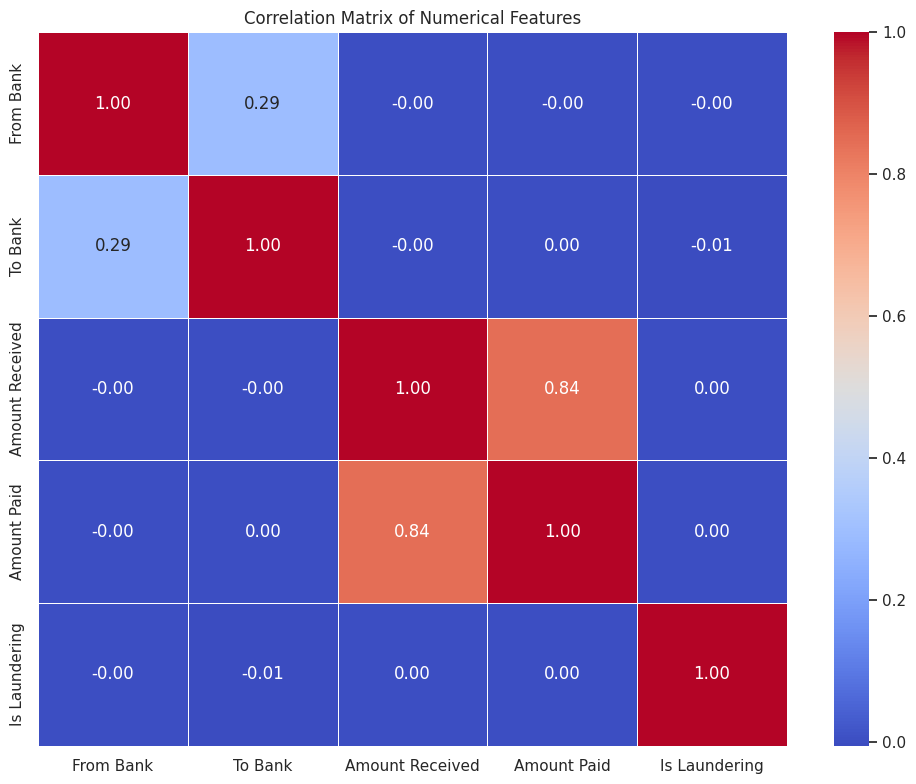

In [12]:
# Correlation matrix (numerical features only)
numerical_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

Total Unique Banks: 30470

Top 10 Banks by transaction volume:
70     449859
10      81629
12      79754
1       62211
15      52511
220     52417
20      41008
3       38413
7       31086
211     30451
Name: From Bank, dtype: int64


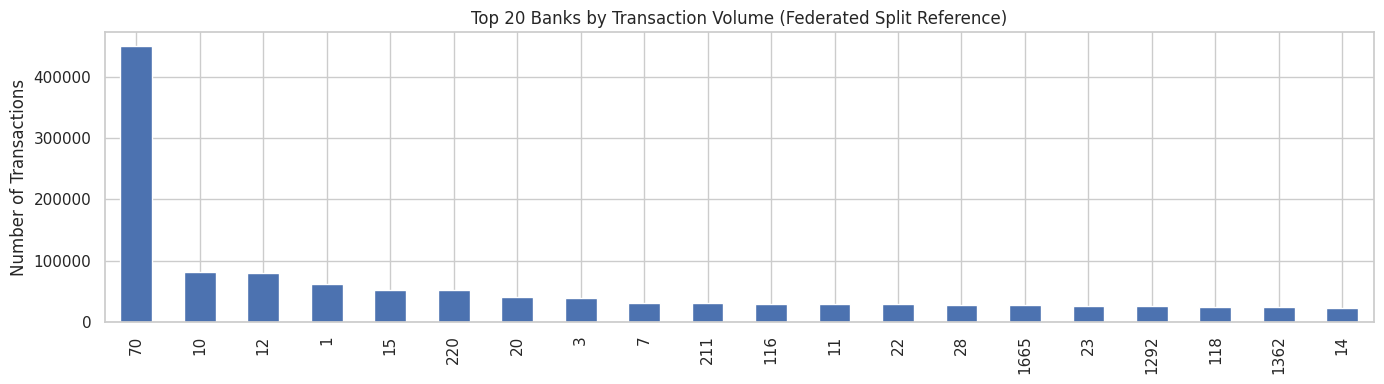


Top 10 Banks by Laundering Rate (min 100 transactions):
           sum  count  laundering_rate
From Bank                             
50528       10    111         0.090090
135981      14    229         0.061135
49365       18    477         0.037736
231212      15    544         0.027574
135403       6    240         0.025000
148350      31   1362         0.022761
214749      16    756         0.021164
50202        5    265         0.018868
232391       8    435         0.018391
26302        9    505         0.017822


In [13]:
# Bank analysis — useful for choosing federated split banks
if 'From Bank' in df.columns:
    print(f"Total Unique Banks: {df['From Bank'].nunique()}")
    print("\nTop 10 Banks by transaction volume:")
    print(df['From Bank'].value_counts().head(10))

    plt.figure(figsize=(14, 4))
    df['From Bank'].value_counts().head(20).plot(kind='bar')
    plt.title('Top 20 Banks by Transaction Volume (Federated Split Reference)')
    plt.ylabel('Number of Transactions')
    plt.tight_layout()
    plt.show()

    # Laundering rate per bank
    bank_stats = df.groupby('From Bank')['Is Laundering'].agg(['sum', 'count'])
    bank_stats['laundering_rate'] = bank_stats['sum'] / bank_stats['count']
    print("\nTop 10 Banks by Laundering Rate (min 100 transactions):")
    print(
        bank_stats[bank_stats['count'] >= 100]
        .sort_values('laundering_rate', ascending=False)
        .head(10)
    )

In [14]:
# 3D PCA visualisation
# Samples to plot (large datasets are subsampled for performance)
MAX_PCA_SAMPLES = 10_000

pca_df = df.select_dtypes(include=['float64', 'int64']).fillna(0).copy()
labels = pca_df.pop('Is Laundering')

if len(pca_df) > MAX_PCA_SAMPLES:
    print(f'Dataset is large — sampling {MAX_PCA_SAMPLES:,} rows for 3D PCA viz...')
    idx = np.random.choice(len(pca_df), MAX_PCA_SAMPLES, replace=False)
    pca_df = pca_df.iloc[idx]
    labels  = labels.iloc[idx]

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_df)

pca = PCA(n_components=3)
components = pca.fit_transform(pca_scaled)
print(f'Explained variance (3 components): {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig = px.scatter_3d(
    components, x=0, y=1, z=2,
    color=labels.astype(str),
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3', 'color': 'Is Laundering'},
    title='3D PCA of Transactions — notice how illicit data overlaps with normal',
    color_discrete_map={'0': 'steelblue', '1': 'crimson'},
    opacity=0.6
)
fig.update_traces(marker=dict(size=2))
fig.show()

Dataset is large — sampling 10,000 rows for 3D PCA viz...
Explained variance (3 components): 99.7%
